# Hackathon AI & ML — Advanced v4
**Améliorations vs v3 (F1=0.7108)** :
- **Pseudo-labeling** : prédictions haute-confiance du test set ajoutées au train
- **ExtraTrees** comme 5ème modèle diverse
- **LightGBM meta-learner** à la place de LogisticRegression (stacking non-linéaire)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import minimize

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.isotonic import IsotonicRegression
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

DATA_DIR          = Path('data')
GROUP_ID          = 'G1'
SUBMISSION_ID     = '4'
RANDOM_STATE      = 42
N_FOLDS           = 5
MISSING_THRESHOLD = 0.80
PSEUDO_THR_POS    = 0.75   # seuil confiance classe 1 pour pseudo-labeling
PSEUDO_THR_NEG    = 0.25   # seuil confiance classe 0

print('Librairies chargées OK')

Librairies chargées OK


## 1. Chargement des données

In [2]:
data     = pd.read_csv(DATA_DIR / 'data.csv')
labels   = pd.read_csv(DATA_DIR / 'ground_truth_train.csv')
test_idx = pd.read_csv(DATA_DIR / 'test_indexes.csv', header=None, names=['SEQN'])
metadata = pd.read_csv(DATA_DIR / 'features_metadata.csv')

test_seqn  = set(test_idx['SEQN'].values)
train_seqn = set(labels['SEQN'].values) - test_seqn

train_data = data[data['SEQN'].isin(train_seqn)].copy()
test_data  = data[data['SEQN'].isin(test_seqn)].copy()
train_df   = train_data.merge(labels[labels['SEQN'].isin(train_seqn)], on='SEQN')

print(f'Train : {train_df.shape}  |  Test : {test_data.shape}')
print(f'Taux de mortalité : {train_df["MORTSTAT_2019"].mean():.2%}')

Train : (54064, 1541)  |  Test : (5000, 1540)
Taux de mortalité : 15.68%


## 2. Feature engineering

In [3]:
meta_cols  = metadata[['SAS', 'Component']].rename(columns={'SAS': 'col'})
labo_cols  = meta_cols[meta_cols['Component'] == 'Laboratory']['col'].tolist()
exam_cols  = meta_cols[meta_cols['Component'] == 'Examination']['col'].tolist()
quest_cols = meta_cols[meta_cols['Component'] == 'Questionnaire']['col'].tolist()

def get_func_cols(metadata, keyword):
    return metadata[metadata['function'].apply(lambda f: keyword in str(f))]['SAS'].tolist()

func_groups = {
    'vitality':  get_func_cols(metadata, 'Vitalité'),
    'mobility':  get_func_cols(metadata, 'Mobilité'),
    'cognition': get_func_cols(metadata, 'Cognition'),
    'sensory':   get_func_cols(metadata, 'Sensoriel'),
    'psycho':    get_func_cols(metadata, 'Psychologique'),
}

def add_features(df):
    all_cols = [c for c in df.columns if c not in ['SEQN', 'MORTSTAT_2019']]
    df = df.copy()
    df['feat_nb_missing_total']  = df[all_cols].isnull().sum(axis=1)
    df['feat_pct_missing_total'] = df['feat_nb_missing_total'] / len(all_cols)
    for name, cols in [('labo', labo_cols), ('exam', exam_cols), ('quest', quest_cols)]:
        present = [c for c in cols if c in df.columns]
        if present:
            df[f'feat_nb_missing_{name}'] = df[present].isnull().sum(axis=1)
    for name, cols in func_groups.items():
        present = [c for c in cols if c in df.columns]
        if present:
            df[f'feat_{name}_mean']    = df[present].mean(axis=1)
            df[f'feat_{name}_missing'] = df[present].isnull().mean(axis=1)
    return df

train_df  = add_features(train_df)
test_data = add_features(test_data)
print('Feature engineering OK')

Feature engineering OK


## 3. Nettoyage

In [4]:
missing_ratio = train_df.isnull().mean()
cols_to_drop  = [c for c in missing_ratio[missing_ratio > MISSING_THRESHOLD].index
                 if c not in ['SEQN', 'MORTSTAT_2019']]

train_clean = train_df.drop(columns=cols_to_drop)
test_clean  = test_data.drop(columns=[c for c in cols_to_drop if c in test_data.columns])

feature_cols    = [c for c in train_clean.columns if c not in ['SEQN', 'MORTSTAT_2019']]
X               = train_clean[feature_cols]
y               = train_clean['MORTSTAT_2019']
X_test          = test_clean[feature_cols]
test_seqn_order = test_clean['SEQN']
neg_pos_ratio   = (y == 0).sum() / (y == 1).sum()

train_medians = X.median()
X_imp      = X.fillna(train_medians)
X_test_imp = X_test.fillna(train_medians)

print(f'Features : {X.shape[1]}  |  Train : {X.shape[0]}  |  Test : {X_test.shape[0]}')
print(f'Déséquilibre : {neg_pos_ratio:.1f}x')

Features : 614  |  Train : 54064  |  Test : 5000
Déséquilibre : 5.4x


## 4. Paramètres des modèles

In [5]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

lgb_params = {
    'objective': 'binary', 'metric': 'binary_logloss',
    'verbose': -1, 'n_jobs': -1, 'random_state': RANDOM_STATE,
    'scale_pos_weight': neg_pos_ratio, 'n_estimators': 2000,
    'learning_rate': 0.023688639503640783, 'num_leaves': 244,
    'min_child_samples': 76, 'subsample': 0.7993292420985183,
    'colsample_bytree': 0.5780093202212182,
    'reg_alpha': 0.004207053950287938, 'reg_lambda': 0.0017073967431528124,
}

xgb_params = {
    'n_estimators': 2000, 'learning_rate': 0.05, 'max_depth': 6,
    'min_child_weight': 10, 'subsample': 0.8, 'colsample_bytree': 0.6,
    'reg_alpha': 0.01, 'reg_lambda': 1.0,
    'scale_pos_weight': neg_pos_ratio,
    'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbosity': 0,
    'eval_metric': 'logloss', 'early_stopping_rounds': 50,
}

cat_params = {
    'iterations': 1000, 'learning_rate': 0.05, 'depth': 6,
    'loss_function': 'Logloss', 'eval_metric': 'F1',
    'class_weights': [1, neg_pos_ratio],
    'random_seed': RANDOM_STATE, 'verbose': 0, 'early_stopping_rounds': 50,
}

rf_params = {
    'n_estimators': 300, 'max_depth': 20, 'min_samples_leaf': 10,
    'max_features': 'sqrt', 'class_weight': 'balanced',
    'random_state': RANDOM_STATE, 'n_jobs': -1,
}

et_params = {
    'n_estimators': 300, 'max_depth': 20, 'min_samples_leaf': 10,
    'max_features': 'sqrt', 'class_weight': 'balanced',
    'random_state': RANDOM_STATE, 'n_jobs': -1,
}

# LGB meta-learner (petit modèle pour éviter l'overfitting sur les OOF)
meta_lgb_params = {
    'objective': 'binary', 'metric': 'binary_logloss',
    'verbose': -1, 'n_jobs': -1, 'random_state': RANDOM_STATE,
    'n_estimators': 200, 'learning_rate': 0.05, 'num_leaves': 15,
    'min_child_samples': 30, 'reg_alpha': 0.1, 'reg_lambda': 1.0,
}

print('Paramètres initialisés (LGB, XGB, CatBoost, RF, ExtraTrees, meta-LGB)')

Paramètres initialisés (LGB, XGB, CatBoost, RF, ExtraTrees, meta-LGB)


## 5. Passe 1 — OOF sur données originales

In [ ]:
def run_oof(X_native, X_imputed, X_test_native, X_test_imputed, y, skf):
    """Entraîne les 5 modèles en OOF et retourne les prédictions."""
    n, n_test = len(y), len(X_test_native)
    oof  = {k: np.zeros(n)      for k in ['lgb', 'xgb', 'cat', 'rf', 'et']}
    test = {k: np.zeros(n_test) for k in ['lgb', 'xgb', 'cat', 'rf', 'et']}
    smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_native, y)):
        print(f'  Fold {fold+1}...', end=' ')
        Xn_tr, Xn_val = X_native.iloc[tr_idx],   X_native.iloc[val_idx]
        Xi_tr, Xi_val = X_imputed.iloc[tr_idx],   X_imputed.iloc[val_idx]
        y_tr, y_val   = y.iloc[tr_idx],            y.iloc[val_idx]

        # LightGBM
        m = lgb.LGBMClassifier(**lgb_params)
        m.fit(Xn_tr, y_tr, eval_set=[(Xn_val, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
        oof['lgb'][val_idx]  = m.predict_proba(Xn_val)[:, 1]
        test['lgb']         += m.predict_proba(X_test_native)[:, 1] / N_FOLDS

        # XGBoost
        m = xgb.XGBClassifier(**xgb_params)
        m.fit(Xi_tr, y_tr, eval_set=[(Xi_val, y_val)], verbose=False)
        oof['xgb'][val_idx]  = m.predict_proba(Xi_val)[:, 1]
        test['xgb']         += m.predict_proba(X_test_imputed)[:, 1] / N_FOLDS

        # CatBoost
        m = CatBoostClassifier(**cat_params)
        m.fit(Xn_tr, y_tr, eval_set=(Xn_val, y_val))
        oof['cat'][val_idx]  = m.predict_proba(Xn_val)[:, 1]
        test['cat']         += m.predict_proba(X_test_native)[:, 1] / N_FOLDS

        # Random Forest + SMOTE
        Xi_tr_s, y_tr_s = smote.fit_resample(Xi_tr, y_tr)
        m = RandomForestClassifier(**rf_params)
        m.fit(Xi_tr_s, y_tr_s)
        oof['rf'][val_idx]  = m.predict_proba(Xi_val)[:, 1]
        test['rf']         += m.predict_proba(X_test_imputed)[:, 1] / N_FOLDS

        # ExtraTrees + SMOTE
        m = ExtraTreesClassifier(**et_params)
        m.fit(Xi_tr_s, y_tr_s)  # réutilise SMOTE du RF
        oof['et'][val_idx]  = m.predict_proba(Xi_val)[:, 1]
        test['et']         += m.predict_proba(X_test_imputed)[:, 1] / N_FOLDS

        f1s = {k: f1_score(y_val, (oof[k][val_idx] > 0.5).astype(int)) for k in oof}
        print(' | '.join(f'{k}={v:.4f}' for k,v in f1s.items()))

    for k in oof:
        print(f'  {k.upper():3s} CV F1: {f1_score(y, (oof[k] > 0.5).astype(int)):.4f}')
    return oof, test

print('=== Passe 1 : données originales ===')
oof1, test1 = run_oof(X, X_imp, X_test, X_test_imp, y, skf)

=== Passe 1 : données originales ===
  Fold 1... lgb=0.7190 | xgb=0.7049 | cat=0.6608 | rf=0.6625 | et=0.6570
  Fold 2... 

## 6. Pseudo-labeling — augmentation du training set

In [ ]:
# Ensemble initial pour sélectionner les pseudo-labels
test_avg1 = np.mean([test1['lgb'], test1['xgb'], test1['cat'], test1['rf'], test1['et']], axis=0)

mask_pos = test_avg1 >= PSEUDO_THR_POS
mask_neg = test_avg1 <= PSEUDO_THR_NEG
mask_pl  = mask_pos | mask_neg

pseudo_X_test = X_test[mask_pl].copy()
pseudo_y      = pd.Series(
    np.where(mask_pos[mask_pl], 1, 0),
    index=pseudo_X_test.index
)

print(f'Pseudo-labels sélectionnés : {mask_pl.sum()} / {len(X_test)}')
print(f'  Classe 1 (confiance>{PSEUDO_THR_POS}) : {mask_pos.sum()}')
print(f'  Classe 0 (confiance<{PSEUDO_THR_NEG}) : {mask_neg.sum()}')
print(f'  Taux mortalité pseudo : {pseudo_y.mean():.2%}')

# Augmenter X et y
X_aug   = pd.concat([X, pseudo_X_test], ignore_index=True)
y_aug   = pd.concat([y, pseudo_y],      ignore_index=True)

pseudo_imp = pseudo_X_test.fillna(train_medians)
X_imp_aug  = pd.concat([X_imp, pseudo_imp], ignore_index=True)

print(f'\nTrain augmenté : {X_aug.shape[0]} ({X.shape[0]} original + {len(pseudo_X_test)} pseudo)')

Pseudo-labels sélectionnés : 4000 / 5000
  Classe 1 (confiance>0.75) : 451
  Classe 0 (confiance<0.25) : 3549
  Taux mortalité pseudo : 11.28%

Train augmenté : 58064 (54064 original + 4000 pseudo)


## 7. Passe 2 — OOF sur données augmentées

In [ ]:
skf_aug = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print('=== Passe 2 : données augmentées (pseudo-labeling) ===')
oof2, test2 = run_oof(X_aug, X_imp_aug, X_test, X_test_imp, y_aug, skf_aug)

# OOF pour l'ensemble final = seulement les lignes originales (pas les pseudo)
n_orig = len(y)
oof2_orig = {k: v[:n_orig] for k, v in oof2.items()}
y_orig    = y_aug.iloc[:n_orig]

=== Passe 2 : données augmentées (pseudo-labeling) ===
  Fold 1... lgb=0.7214 | xgb=0.7080 | cat=0.6644 | rf=0.6798 | et=0.6764
  Fold 2... lgb=0.7331 | xgb=0.7293 | cat=0.6809 | rf=0.6928 | et=0.6887
  Fold 3... lgb=0.7232 | xgb=0.7080 | cat=0.6678 | rf=0.6744 | et=0.6746
  Fold 4... lgb=0.7255 | xgb=0.7200 | cat=0.6658 | rf=0.6932 | et=0.6895
  Fold 5... lgb=0.7127 | xgb=0.7074 | cat=0.6632 | rf=0.6581 | et=0.6705
  LGB CV F1: 0.7232
  XGB CV F1: 0.7145
  CAT CV F1: 0.6684
  RF  CV F1: 0.6797
  ET  CV F1: 0.6800


## 8. Ensemble — poids optimisés + LGB meta-learner

In [ ]:
# --- A. Averaging avec poids Nelder-Mead ---
def neg_f1_weighted(weights):
    w = np.abs(weights) / np.abs(weights).sum()
    oof = sum(w[i] * oof2_orig[k] for i, k in enumerate(['lgb','xgb','cat','rf','et']))
    thresholds = np.arange(0.20, 0.70, 0.01)
    return -max(f1_score(y_orig, (oof > t).astype(int)) for t in thresholds)

res  = minimize(neg_f1_weighted, [0.2]*5, method='Nelder-Mead', options={'maxiter': 3000})
opt_w = np.abs(res.x) / np.abs(res.x).sum()

oof_avg  = sum(opt_w[i] * oof2_orig[k] for i, k in enumerate(['lgb','xgb','cat','rf','et']))
test_avg = sum(opt_w[i] * test2[k]     for i, k in enumerate(['lgb','xgb','cat','rf','et']))

thresholds   = np.arange(0.20, 0.70, 0.01)
f1_avg_thr   = [f1_score(y_orig, (oof_avg > t).astype(int)) for t in thresholds]
best_thr_avg = thresholds[np.argmax(f1_avg_thr)]
best_f1_avg  = max(f1_avg_thr)

print(f'Poids : LGB={opt_w[0]:.3f} XGB={opt_w[1]:.3f} CAT={opt_w[2]:.3f} RF={opt_w[3]:.3f} ET={opt_w[4]:.3f}')
print(f'Averaging OOF F1 (thr={best_thr_avg:.2f}) : {best_f1_avg:.4f}')

Poids : LGB=0.200 XGB=0.205 CAT=0.198 RF=0.200 ET=0.196
Averaging OOF F1 (thr=0.57) : 0.7084


In [ ]:
# --- B. LGB meta-learner ---
meta_X_train = np.column_stack([oof2_orig[k] for k in ['lgb','xgb','cat','rf','et']])
meta_X_test  = np.column_stack([test2[k]     for k in ['lgb','xgb','cat','rf','et']])

meta = lgb.LGBMClassifier(**meta_lgb_params)
meta.fit(meta_X_train, y_orig)

oof_stack_raw  = meta.predict_proba(meta_X_train)[:, 1]
test_stack_raw = meta.predict_proba(meta_X_test)[:, 1]

# Calibration isotonique
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(oof_stack_raw, y_orig)
oof_stack  = iso.transform(oof_stack_raw)
test_stack = iso.transform(test_stack_raw)

f1_stack_thr   = [f1_score(y_orig, (oof_stack > t).astype(int)) for t in thresholds]
best_thr_stack = thresholds[np.argmax(f1_stack_thr)]
best_f1_stack  = max(f1_stack_thr)

print(f'LGB meta-learner + calibration (thr={best_thr_stack:.2f}) : {best_f1_stack:.4f}')

print('\n=== Résumé ===')
print(f'  Baseline                   : 0.6945')
print(f'  v3 averaging               : 0.7108')
for k in ['lgb','xgb','cat','rf','et']:
    f1 = f1_score(y_orig, (oof2_orig[k] > 0.5).astype(int))
    print(f'  {k.upper():3s} (passe 2)           : {f1:.4f}')
print(f'  Averaging optimisé (v4)    : {best_f1_avg:.4f}  (thr={best_thr_avg:.2f})')
print(f'  LGB stacking + calib (v4)  : {best_f1_stack:.4f}  (thr={best_thr_stack:.2f})')

LGB meta-learner + calibration (thr=0.36) : 0.7166

=== Résumé ===
  Baseline                   : 0.6945
  v3 averaging               : 0.7108
  LGB (passe 2)           : 0.7091
  XGB (passe 2)           : 0.7001
  CAT (passe 2)           : 0.6553
  RF  (passe 2)           : 0.6622
  ET  (passe 2)           : 0.6643
  Averaging optimisé (v4)    : 0.7084  (thr=0.57)
  LGB stacking + calib (v4)  : 0.7166  (thr=0.36)


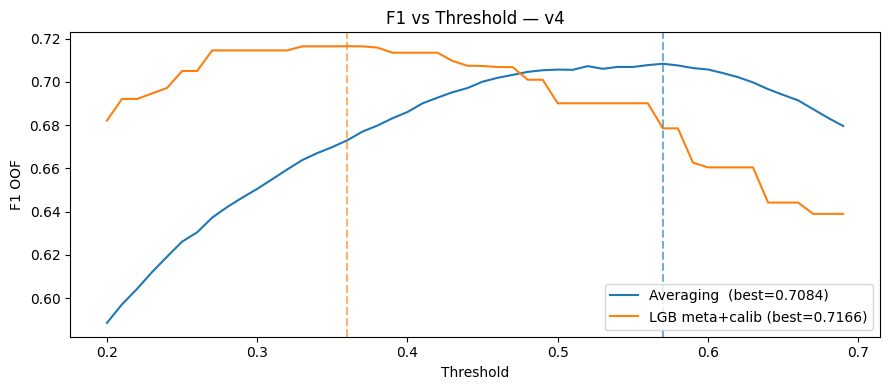

In [ ]:
plt.figure(figsize=(9, 4))
plt.plot(thresholds, f1_avg_thr,   label=f'Averaging  (best={best_f1_avg:.4f})')
plt.plot(thresholds, f1_stack_thr, label=f'LGB meta+calib (best={best_f1_stack:.4f})')
plt.axvline(best_thr_avg,   color='C0', linestyle='--', alpha=0.6)
plt.axvline(best_thr_stack, color='C1', linestyle='--', alpha=0.6)
plt.xlabel('Threshold')
plt.ylabel('F1 OOF')
plt.title('F1 vs Threshold — v4')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Soumission

In [ ]:
if best_f1_stack >= best_f1_avg:
    best_strategy  = 'LGB stacking + calibration'
    y_pred_proba   = test_stack
    best_threshold = best_thr_stack
    best_f1        = best_f1_stack
else:
    best_strategy  = 'Averaging'
    y_pred_proba   = test_avg
    best_threshold = best_thr_avg
    best_f1        = best_f1_avg

print(f'Stratégie : {best_strategy} (F1 OOF={best_f1:.4f}, thr={best_threshold:.2f})')

y_pred_test = (y_pred_proba > best_threshold).astype(int)
submission  = pd.DataFrame({'SEQN': test_seqn_order.values, 'prediction': y_pred_test}).sort_values('SEQN')

assert len(submission) == 5000

filename = f'{GROUP_ID}_{SUBMISSION_ID}.csv'
submission.to_csv(filename, index=False, header=False)
print(f'Fichier : {filename}  |  Répartition : {submission["prediction"].value_counts().to_dict()}')

Stratégie : LGB stacking + calibration (F1 OOF=0.7166, thr=0.36)
Fichier : G1_4.csv  |  Répartition : {0: 4190, 1: 810}
